In [3]:
import pandas as pd
import numpy as np
import geopy.distance # pip install geopy library
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#this seed has been set to 100 in all cells to ensure results are reproducible. DO NOT CHANGE THIS SEED
np.random.seed(100)
# libraries used
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from scipy.stats import chi2
from sklearn.model_selection import GridSearchCV
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix



In [3]:
warnings.filterwarnings("ignore", category=FutureWarning) # Ignore warnings

airline_df = pd.read_excel('../data/AirportPassengers.xlsx') # passengers count
visitors_df = pd.read_excel('../data/InternationalVisitors.xlsx')
# House Price - ALL cities 
zillow_df = pd.read_csv('../data/Zillow_Value_AllCities.csv')  # https://www.zillow.com/research/data/ 

#Population
bos_pop_df = pd.read_csv("../data/BOS_population.csv") # https://data.boston.gov/dataset/2020-census-for-boston/resource/5800a0a2-6acd-41a3-9fe0-1bf7b038750d
den_pop_df = pd.read_csv("../data/DEN_population.csv") # https://catalog.data.gov/dataset/2010-census-populations-by-zip-code
lax_pop_df = pd.read_csv("../data/LAX_population.csv") # https://data.lacounty.gov/datasets/lacounty::2020-census-blocks/about?layer=3
nyc_pop_df = pd.read_csv("../data/NYC_population.csv") # https://catalog.data.gov/dataset/new-york-city-population-by-neighborhood-tabulation-areas



#Rename columns for population data for neighbourhood
bos_pop_df = bos_pop_df.rename(columns={"tract20_nbhd": "neighbourhood", "P0020001": "population" })
den_pop_df = den_pop_df.rename(columns={"NAME": "neighbourhood", "SUM_POPULATION_2010": "population" })
nyc_pop_df = nyc_pop_df.rename(columns={"NTA Name": "neighbourhood", "Population": "population" })
lax_pop_df = lax_pop_df.rename(columns={"COMM": "neighbourhood", "POP20": "population" })

#Rename column for airport arrival passengers and international visitors
airline_df = airline_df.rename(columns={"DEST": "airport_code", "PASSENGERS": "passengers" })
visitors_df = visitors_df.rename(columns={"U.S. MSAs Visited": "city", "Expanded Estimates": "visitors" })

# Airbnb Listing for Short and Long Term Rental https://insideairbnb.com/get-the-data/
bos_df = pd.read_csv("../data/BOS_Listings.csv")
den_df = pd.read_csv("../data/DEN_Listings.csv")
lax_df = pd.read_csv("../data/LAX_Listings.csv")
nyc_df = pd.read_csv("../data/NYC_Listings.csv")



In [166]:
# Define metadata and date columns
house_price_df = zillow_df
columns = ['RegionName',
           'State', 'City']
date_columns = [col for col in house_price_df.columns if col not in columns]

# Reshape from wide to long format
house_price_df = pd.melt(
    house_price_df,
    id_vars=columns,
    value_vars=date_columns,
    var_name='Date',
    value_name='house_value'
)

house_price_df['Date'] = pd.to_datetime(house_price_df['Date'], errors='coerce', infer_datetime_format=True)
house_price_df = house_price_df.dropna(subset=['Date'])
most_recent_date = house_price_df['Date'].max()
house_price_df = house_price_df[house_price_df['Date'] == most_recent_date]
#house_price_df['house_value'] = house_price_df['house_value'].apply(lambda x: f"{x:,.2f}")
house_price_df['house_value'] = house_price_df['house_value'].fillna(0)
#house_price_df = house_price_df[house_price_df["RegionName"] == "East Colfax"]
#house_price_df = house_price_df.drop(columns=columns)
print(house_price_df.head())



                RegionName State         City       Date   house_value
7343440           Maryvale    AZ      Phoenix 2025-02-28  3.376712e+05
7343441           Paradise    NV    Las Vegas 2025-02-28  4.407130e+05
7343442    Upper West Side    NY     New York 2025-02-28  2.954627e+06
7343443    Upper East Side    NY     New York 2025-02-28  4.636830e+06
7343444  South Los Angeles    CA  Los Angeles 2025-02-28  6.947944e+05


In [167]:
# Merge and rank cities based on airport passenger volume and international visitors
# Step 2: Process airport and fare data
# airline_df['city'] = airline_df['city'].apply(lambda x: x.split(',')[0].strip())
# airline_df = airline_df.groupby('city')['passengers'].sum().reset_index()

# Step 3: Process international visitors data 
# get city from first column
# visitors_df['city'] = visitors_df['city'].apply(lambda x: x.split(',')[0].strip())
# visitors_df = visitors_df.groupby('city')['visitors'].sum().reset_index()
# 
# print(visitors_df)
# df = df.merge(pass_vol_df[['airport_code', 'passengers']], on='airport_code',  how='left')
# df = df.merge(visitors_df[['city','visitors']], left_on='airport_city', right_on='city')
    



In [168]:
def add_city(listing_df, pop_df, pass_vol_df, visitors_df, airport_city, airport_code, airport_coords):
    air_location = tuple(airport_coords)
    df  = listing_df
    
    # Step 1: Clean and filter listings
    columns_to_drop_initial = ['name', 'license', 'host_name', 'id', 'host_id', 'calculated_host_listings_count']
    long_stay_threshold = 14 
    no_review_threshold = 10

    #df = df.drop(columns=columns_to_drop_initial).dropna()
    # Commented to analyze more neighbourhoods
    # df = df.drop(columns=columns_to_drop_initial, errors='ignore').dropna(subset=['latitude', 'longitude'])
    # popular_neighbourhoods = (
    #     df['neighbourhood'].value_counts()[lambda x: x > 100].index
    # )
    # df = df[df['neighbourhood'].isin(popular_neighbourhoods)]
    
    # Commented to get all reviews     
    # df = df[df['last_review'] > '2024-01-01']
    # df = df[df['number_of_reviews_ltm'] > no_review_threshold]
    # df = df.reset_index(drop=True)


    df['long_stay'] = np.where(df['minimum_nights'] > long_stay_threshold, 1, 0)
    df['airport_city'] = airport_city
    df['airport_code'] = airport_code

    # airport_data = pd.merge(passenger_count, fares_df, left_on='ORIGIN', right_on='Airport Code')
    # airport_data = airport_data[['Airport Code','Airport Name','City Name','State Name', 'PASSENGERS', 'Average Fare ($)']] 
    # airport_data.columns = ['airport_code','airport_name', 'airport_city', 'airport_state','passenger_count','average_fare']

    # Step 3: Calculate distance from airport
    def calculate_distance(row):
        listing_location = (row['latitude'], row['longitude'])
        return geopy.distance.geodesic(air_location, listing_location).miles
    
    df['distance_from_airport'] = df.apply(calculate_distance, axis=1)

    # Merge population data 
    df = df.merge(pop_df[['neighbourhood', 'population']], on='neighbourhood', how='left')
    # Merge Airport Passengers Volume

  # Step 2: Process airport and fare data
    pass_vol_df = pass_vol_df[pass_vol_df['airport_code'] == airport_code]
    pass_vol_df = pass_vol_df.groupby('airport_code')['passengers'].sum().reset_index()
    
  # Step 3: Process international visitors data 
    # get city from first column
    visitors_df['city'] = visitors_df['city'].apply(lambda x: x.split('-')[0].strip())

    visitors_df = visitors_df[visitors_df['city'] == airport_city]
    visitors_df = visitors_df.groupby('city')['visitors'].sum().reset_index()

    df = df.merge(pass_vol_df[['airport_code', 'passengers']], on='airport_code',  how='left')
    df = df.merge(visitors_df[['city','visitors']], left_on='airport_city', right_on='city')
    columns_to_drop = [col for col in ['latitude', 'longitude', 'airport_city_x'] if col in df.columns]
    
    df_listings = df.drop(columns=columns_to_drop)

    # Step 5: Merge with Zillow data
    neighbourhood = df_listings.merge(house_price_df, how='left', left_on=['neighbourhood','airport_city'], right_on=['RegionName','City'])


    # 🔍 Debug print to help verify house_value is present
    #print("Columns after Zillow merge:", neighbourhood.columns.tolist())
    # Step 6: Drop columns if they exist
    columns_to_drop = [col for col in ['latitude', 'longitude', 'airport_city_x'] if col in neighbourhood.columns]
    df = neighbourhood.drop(columns=columns_to_drop)

    
    
    # Replace NaN and None to 0
    df['population'] = df['population'].fillna(0).astype(int)
    df['house_value'] = df['house_value'].fillna(0)

# Create long_stay and short_stay as separate binary columns
    df["long_term_stays"] = (df["long_stay"] == 1).astype(int)
    df["short_term_stay"] = (df["long_stay"] == 0).astype(int)

    # Step 7: Group and aggregate
    agg_dict = {
        'price': 'mean',
        'availability_365': 'mean',
        'minimum_nights': 'mean',
        'long_term_stays': 'mean',
        'short_term_stay': 'mean',
        'reviews_per_month': 'mean',
        'number_of_reviews_ltm': ['mean', 'sum'],
        'distance_from_airport': 'mean',
        'population': 'mean',
        'house_value': 'mean',
        'neighbourhood': 'count',
        'passengers': 'mean',
        'visitors': 'mean',
        'airport_code': 'first'
    }

    if 'house_value' in df.columns:
        agg_dict['house_value'] = 'first'

    df_listings_group = df.groupby(['neighbourhood']).agg(agg_dict).rename(
        columns={'neighbourhood': 'neighbourhood_count'}).reset_index()
    #print(df_listings_group)
    return df_listings_group


In [170]:
BOS = add_city(bos_df, bos_pop_df, airline_df, visitors_df, 'Boston', 'BOS', (42.36429977,	-71.00520325))
DEN = add_city(den_df, den_pop_df, airline_df, visitors_df, 'Denver', 'DEN', (39.8561, -104.6737))
LAX = add_city(lax_df, lax_pop_df, airline_df, visitors_df, 'Los Angeles', 'LAX', (33.9416, -118.4085))
NYC = add_city(nyc_df, nyc_pop_df, airline_df, visitors_df, 'New York', 'LGA', (40.7769, -73.8740))

combined_df = pd.concat([BOS, DEN, LAX, NYC], ignore_index=True)
combined_df = combined_df.convert_dtypes()
# int_cols = [
#     'availability_365', 'minimum_nights',
#     'reviews_per_month', 'number_of_reviews_ltm', 
#     'population', 'house_value',
#     'passengers', 'visitors'
# ]
# for col in int_cols:
#     combined_df[col] = combined_df[col].fillna(0).astype(int)

numeric_cols = combined_df.select_dtypes(include=['number']).columns
# Round numeric columns to 2 decimal places
combined_df[numeric_cols] = combined_df[numeric_cols].round(2)

print(combined_df)
combined_df.to_csv("../data/final_dataset.csv", index=False)

       neighbourhood   price availability_365 minimum_nights long_term_stays  \
                        mean             mean           mean            mean   
0            Allston  131.82           191.63           48.9            0.73   
1           Back Bay  243.53           197.03          24.97            0.58   
2        Bay Village  348.24           226.08          11.32            0.24   
3        Beacon Hill  148.19           131.54          29.64            0.74   
4           Brighton  150.06           179.87          35.93            0.64   
..               ...     ...              ...            ...             ...   
587  Windsor Terrace  176.42           138.53          39.06             0.9   
588        Woodhaven   86.14           187.91         101.09            0.88   
589         Woodlawn   141.5           249.12          19.75            0.62   
590          Woodrow    58.5            365.0           30.0             1.0   
591         Woodside   86.62            

# Individual Analysis
# 1. Exploratory Data Analysis

a. Split the data into 80% training and 20% test sets

In [4]:
df = pd.read_csv('../data/final_dataset.csv') 
df = df.iloc[1:].reset_index(drop=True) # skip first index row with summary labels generated by agg_dict

sample = np.random.choice(df.index, size=int(np.ceil(0.80 * len(df))), replace=False)
train_house_data = df.loc[sample]
test_house_data = df.drop(sample)

# Remove row names (reset index)
train_house_data = train_house_data.reset_index(drop=True)
test_house_data = test_house_data.reset_index(drop=True)

# Print the first 5 rows of both datasets
print("First 5 rows of the training set:")
print(train_house_data.head())

print("\nFirst 5 rows of the test set:")
print(test_house_data.head())

First 5 rows of the training set:
     neighbourhood   price availability_365 minimum_nights long_term_stays  \
0          Belcaro  402.07           192.56          33.94            0.69   
1      South Beach   91.56           299.33          26.78            0.89   
2  Lighthouse Hill   185.0            221.5           30.0             1.0   
3          Burbank  238.51           182.03           9.64            0.21   
4            Acton   125.0            192.0           4.93            0.07   

  short_term_stay reviews_per_month number_of_reviews_ltm  \
0            0.31              0.63                  2.38   
1            0.11              1.41                  5.44   
2             0.0              0.47                   0.0   
3            0.79              2.31                 17.23   
4            0.93              0.92                  6.86   

  number_of_reviews_ltm.1 distance_from_airport population house_value  \
0                      38                 18.04     4172

b. Summary statistics
  

In [5]:

display(combined_df[['price', 'distance_from_airport', 'population', 'passengers', 'visitors', 'house_value']].describe())

NameError: name 'combined_df' is not defined


c. Display Bar graphs for following to visualize data

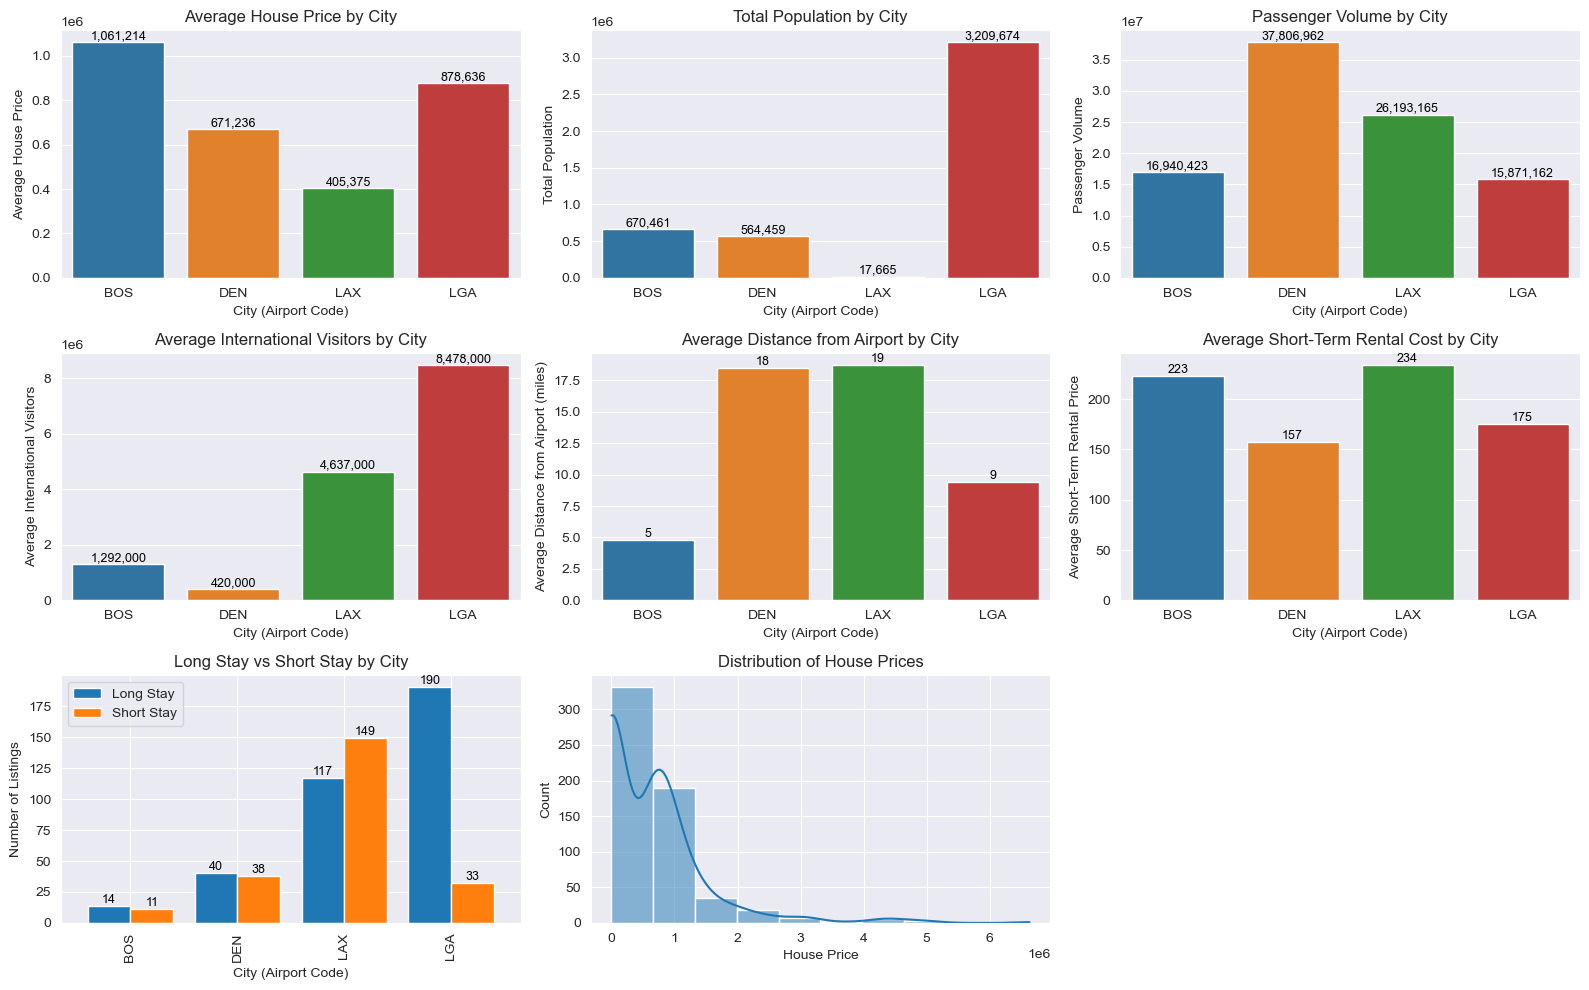

In [293]:
# Convert to numeric to plot values 
df['house_value'] = pd.to_numeric(df['house_value'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df['passengers'] = pd.to_numeric(df['passengers'], errors='coerce')
df['visitors'] = pd.to_numeric(df['visitors'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['distance_from_airport'] = pd.to_numeric(df['distance_from_airport'], errors='coerce')
df['long_term_stays'] = pd.to_numeric(df['long_term_stays'], errors='coerce')
df['short_term_stay'] = pd.to_numeric(df['short_term_stay'], errors='coerce')


agg_dict = {
    'house_value': 'mean',
    'population': 'sum',
    'passengers': 'mean',
    'visitors': 'mean',
    'price': 'mean',
    'distance_from_airport': 'mean',
    'long_term_stays': 'sum',
    'short_term_stay': 'sum'
}

city_summary = df.groupby('airport_code').agg(agg_dict).reset_index()
city_summary = city_summary.rename(columns={
    'house_value': 'House Price',
    'population': 'Total Population',
    'passengers': 'Passenger Volume',
    'visitors': 'International Visitors',
    'price': 'Short-Term Rentals Cost',
    'distance_from_airport': 'Airport Distance',
    'long_term_stays': 'Long-Term Stay',
    'short_term_stay': 'Short-Term Stay'
})
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

plots = [
    ('House Price', 'Average House Price by City', 'Average House Price', axes[0, 0]),
    ('Total Population', 'Total Population by City', 'Total Population', axes[0, 1]),
    ('Passenger Volume', 'Passenger Volume by City', 'Passenger Volume', axes[0, 2]),
    ('International Visitors', 'Average International Visitors by City', 'Average International Visitors', axes[1, 0]),
    ('Airport Distance', 'Average Distance from Airport by City', 'Average Distance from Airport (miles)', axes[1, 1]),
    ('Short-Term Rentals Cost', 'Average Short-Term Rental Cost by City', 'Average Short-Term Rental Price', axes[1, 2])
]

for col, title, ylabel, ax in plots:
    sns.barplot(x='airport_code', y=col, data=city_summary, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('City (Airport Code)')
    ax.set_ylabel(ylabel)
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(f'{value:,.0f}',
                    (p.get_x() + p.get_width() / 2., value),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

# Merge long_stay and short_stay into a single bar plot with increased width and value labels
stay_counts = city_summary[['airport_code', 'Long-Term Stay', 'Short-Term Stay']].set_index('airport_code')
stay_ax = axes[2, 0]
stay_counts.plot(kind='bar', stacked=False, ax=stay_ax, color=['#1f77b4', '#ff7f0e'], width=0.8)
stay_ax.set_title('Long Stay vs Short Stay by City')
stay_ax.set_xlabel('City (Airport Code)')
stay_ax.set_ylabel('Number of Listings')
stay_ax.legend(['Long Stay', 'Short Stay'])

# Add value labels on each bar for long_stay and short_stay
for container in stay_ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            stay_ax.annotate(f'{height:,.0f}',
                             (bar.get_x() + bar.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=9, color='black', rotation=0)

sns.histplot(df['house_value'], bins=10, kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Distribution of House Prices')
axes[2, 1].set_xlabel('House Price')
axes[2, 1].set_ylabel('Count')

# Hide unused subplots
axes[2, 2].axis('off')


plt.tight_layout()
plt.show()


1. Average House Price by City: Apparently, Boston has highest house price, followed by New York indicating city-specific factors have a significant impact on housing prices and should be accounted for in both MLR and XGBoost models. 
2. Average House Price by City: LGA has a much higher population (~3.2M) than other cities; LAX and BOS significantly lower. Population reflects a continuous variable that may influence housing prices. It is useful in to identify demand-driven price increases.
3. Passenger Volume by City: DEN has the highest air traffic (~37M), followed by LAX. Passenger_volume can serve as a proxy for accessibility and economic activity, particularly in areas close to airports.
We can leverage this to assess economic vibrancy around the airport.
4. Average International Visitors by City: LGA and LAX attract significantly more visitors, suggesting strong tourism or global connectivity. It impacts short-term rental profitability, which in turn can indirectly affect real estate investment decisions and property pricing. This variable may enhance XGBoost model performance by capturing its nonlinear effects.
5. Average Distance from Airport by City: BOS is closest (~5 mi); LAX and DEN are further (~18–19 mi). Distance_from_airport reflects location accessibility, a key factor that directly influences a property's desirability and value. It's important for MLR to capture its linear impact, while XGBoost can detect any threshold-based or nonlinear effects it may have.
6. Average Short-Term Rental Cost by City: LAX shows the highest average rental price 234k, highlighting strong market profitability. Rental income serves as a key investment indicator and often correlates with house price growth. This variable can help MLR identify correlations and enable XGBoost to capture rent-driven price surges.
7. Long Stay vs. Short Stay by City: LAX and LGA show higher volumes of both short- and long-term stays, while BOS has minimal activity. The binary flags for long_stay and short_stay help indicate the property's primary use—whether it's residential or for investment purposes. These variables are valuable for both MLR and XGBoost, as they help the models differentiate property utility when predicting prices.
8. House Price Distribution: The data is heavily right-skewed, with most listings priced under 2M, but a few outliers reaching over 6M. Applying a log transformation may be necessary in MLR to improve normality. While XGBoost is naturally better at handling skewed distributions, it can still benefit from transformation for improved performance.

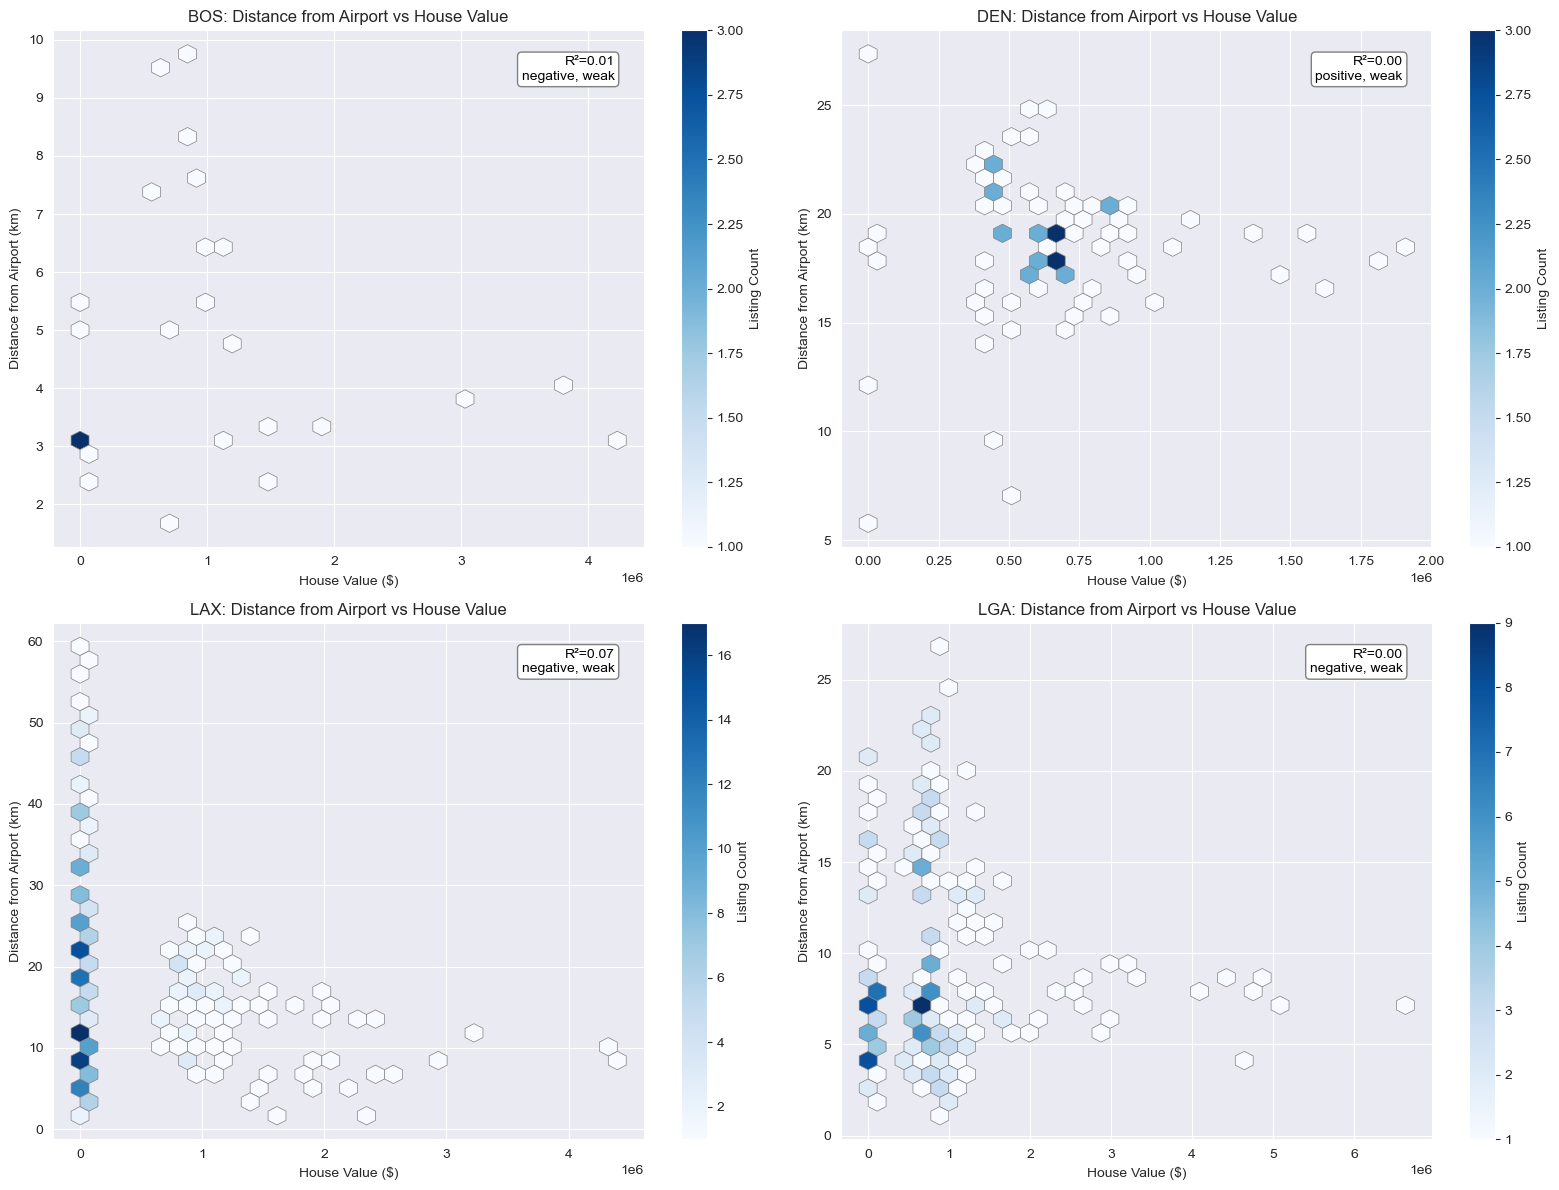

In [294]:
from scipy.stats import linregress

# Get unique cities
cities = df['airport_code'].dropna().unique()

# Set up 2x2 grid for up to 4 cities
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, city in enumerate(cities):  
    city_df = df[df['airport_code'] == city]
    hb = axes[idx].hexbin(
        x=city_df['house_value'],
        y=city_df['distance_from_airport'],
        gridsize=30,
        cmap='Blues',
        mincnt=1,
        linewidths=0.5,
        edgecolors='gray'
    )
    axes[idx].set_title(f"{city}: Distance from Airport vs House Value")
    axes[idx].set_xlabel("House Value ($)")
    axes[idx].set_ylabel("Distance from Airport (km)")
    fig.colorbar(hb, ax=axes[idx], label='Listing Count')

    # Ref: HW2 - Correlation Analysis per City 
    if city_df['house_value'].nunique() > 1 and city_df['distance_from_airport'].nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(
            city_df['house_value'],
            city_df['distance_from_airport']
        )
        r_squared = r_value ** 2
        # Comment on the direction and strength of the correlation
        if r_value > 0:
            direction = "positive"
        else:
            direction = "negative"

        if r_squared <= 0.3:
            strength = "weak"
        elif 0.3 < r_squared < 0.7:
            strength = "moderate"
        else:
            strength = "strong"
        
        # Ref Stack Overflow to print R2, direction and strength as legend.
        axes[idx].annotate(
        f"R²={r_squared:.2f}\n{direction}, {strength}",
        xy=(0.95, 0.95), xycoords='axes fraction',  # right top
        ha='right', va='top', fontsize=10, color='black',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1)
        )



plt.tight_layout()
plt.show()

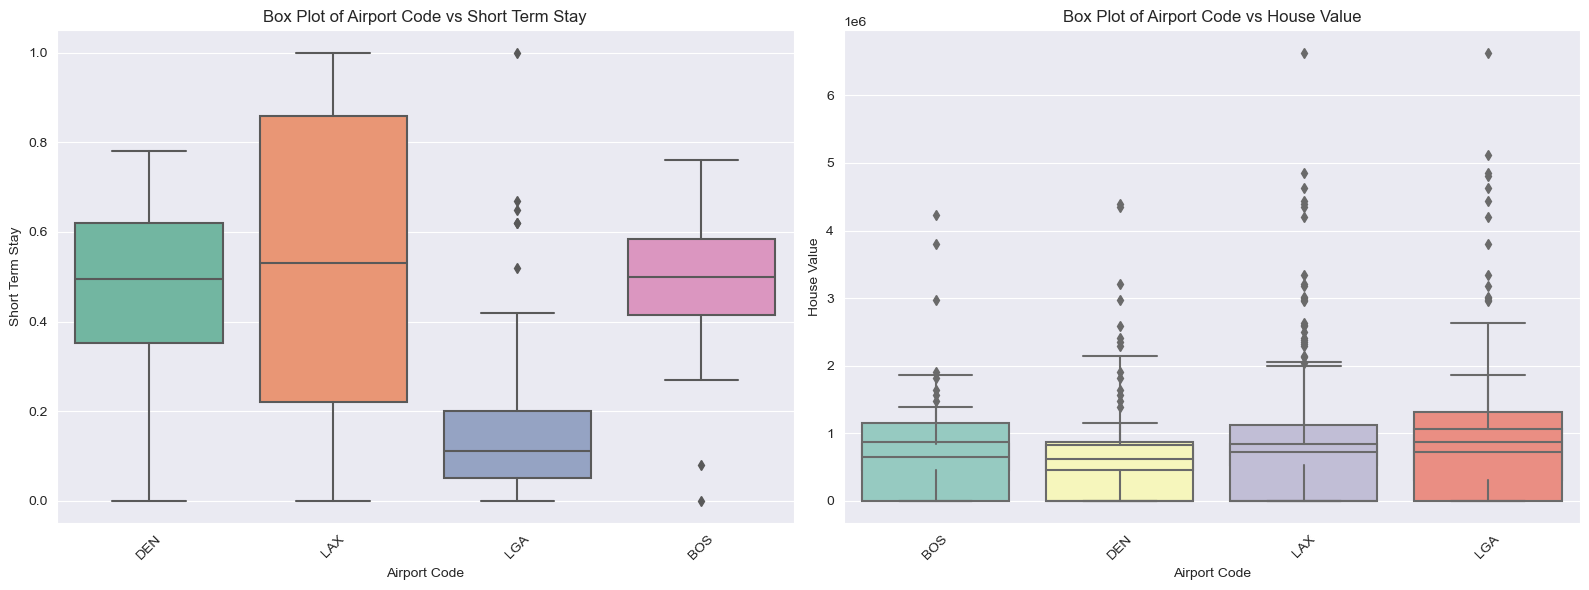

In [295]:
train_house_data['house_value'] = pd.to_numeric(train_house_data['house_value'], errors='coerce')
train_house_data['short_term_stay'] = pd.to_numeric(train_house_data['short_term_stay'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Airport Code vs Short Term Stay
sns.boxplot(data=train_house_data, x='airport_code', y='short_term_stay', palette='Set2', ax=axes[0])
axes[0].set_title("Box Plot of Airport Code vs Short Term Stay")
axes[0].set_xlabel("Airport Code")
axes[0].set_ylabel("Short Term Stay")
axes[0].tick_params(axis='x', rotation=45)

# Box plot: Airport Code vs House Value
sns.boxplot(data=train_house_data, x='airport_code', y='house_value', palette='Set3', ax=axes[1])
axes[1].set_title("Box Plot of Airport Code vs House Value")
axes[1].set_xlabel("Airport Code")
axes[1].set_ylabel("House Value")
axes[1].tick_params(axis='x', rotation=45)

# Correlation Heat map
sns.boxplot(data=df, x='airport_code', y='house_value', palette='Set3', ax=axes[1])
axes[1].set_title("Box Plot of Airport Code vs House Value")
axes[1].set_xlabel("Airport Code")
axes[1].set_ylabel("House Value")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Left Chart: Box Plot of City vs Short Term Stay exhibits LAX has the highest concentration and variability in short-term stays, with a median around 0.6, indicating a significant presence of short-term rental activity.
In contrast, LGA has a relatively low median, suggesting a smaller proportion of properties used for short-term rentals—potentially reflecting fewer investment-oriented listings.
DEN and BOS display a more moderate distribution, suggesting a balanced mix of both short- and long-term stays.

The rate of short-term stays serves as a valuable predictor of a property's intended use—whether for investment or residential purposes.
Cities like LAX, where short-term rentals are more dominant, may experience price pressures due to tourism demand, a factor worth capturing in predictive models.
In a Multiple Linear Regression (MLR) framework, this variable would contribute linearly, while XGBoost could uncover nonlinear interactions between short-term rentals, proximity to airports, and pricing trends.

Right Chart: Box Plot of Airport Code vs House Value show house price distribution (house_value) for each airport city. BOS and LGA show higher median house values than LAX and DEN. Outliers exist in all cities, with LAX and LGA having the most extreme values (up to 6.5M). LAX has a wider spread in values despite a lower median—indicating both affordable and luxury listings.
airport_code can be encoded as a categorical variable representing city-level price influences. Differences in price distributions among cities justify the inclusion of this factor in the regression equation. XGBoost can further explore complex, nonlinear relationships like "LAX + short_term_stay + distance_from_airport = high price" clusters.

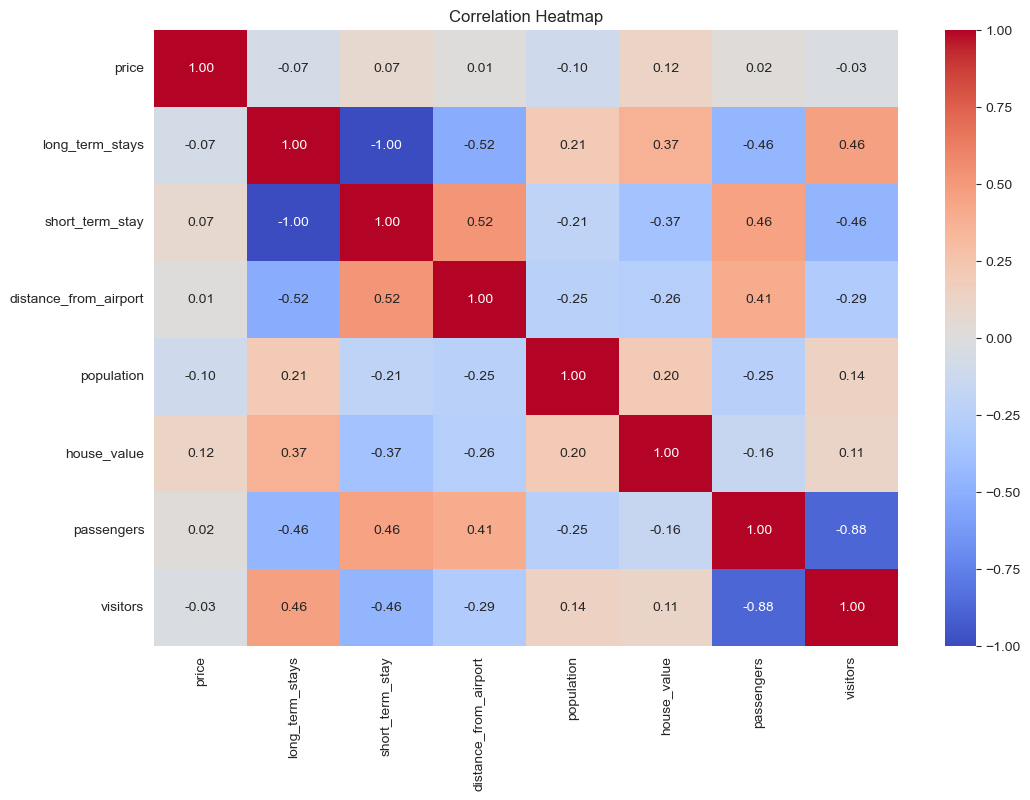

In [296]:
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

This heatmap visualizes pairwise correlation coefficients between variables in the dataset, ranging from -1 to 1.
long_term_stay and short_term_stay shows strong relationship with perfect -1.00 followed by passengers and visitors with -0.88 correlations and indicates multi collinearity.
long_term_stay shows moderate positive relationship with house values (0.37) suggesting long-term rentals are more common in higher value housing markets.
Variables like price, population, and passengers show weak correlation with house_value, which might be nonlinear relationships.
Variable used for MLR are long_term_stays, distance_from_airport, and short_term_stay.
Since XGB, can handle high-dimensional data better, we can use (distance_from_airport + short_term_stay) → higher house value and (airport_city + visitors) → dynamic tourism effects.
it can also capture nonlinear patterns and interactions (e.g., passengers vs. house value), even when linear correlation is weak.

Linearity test for,
 1. Rental Prices vs House Prices 


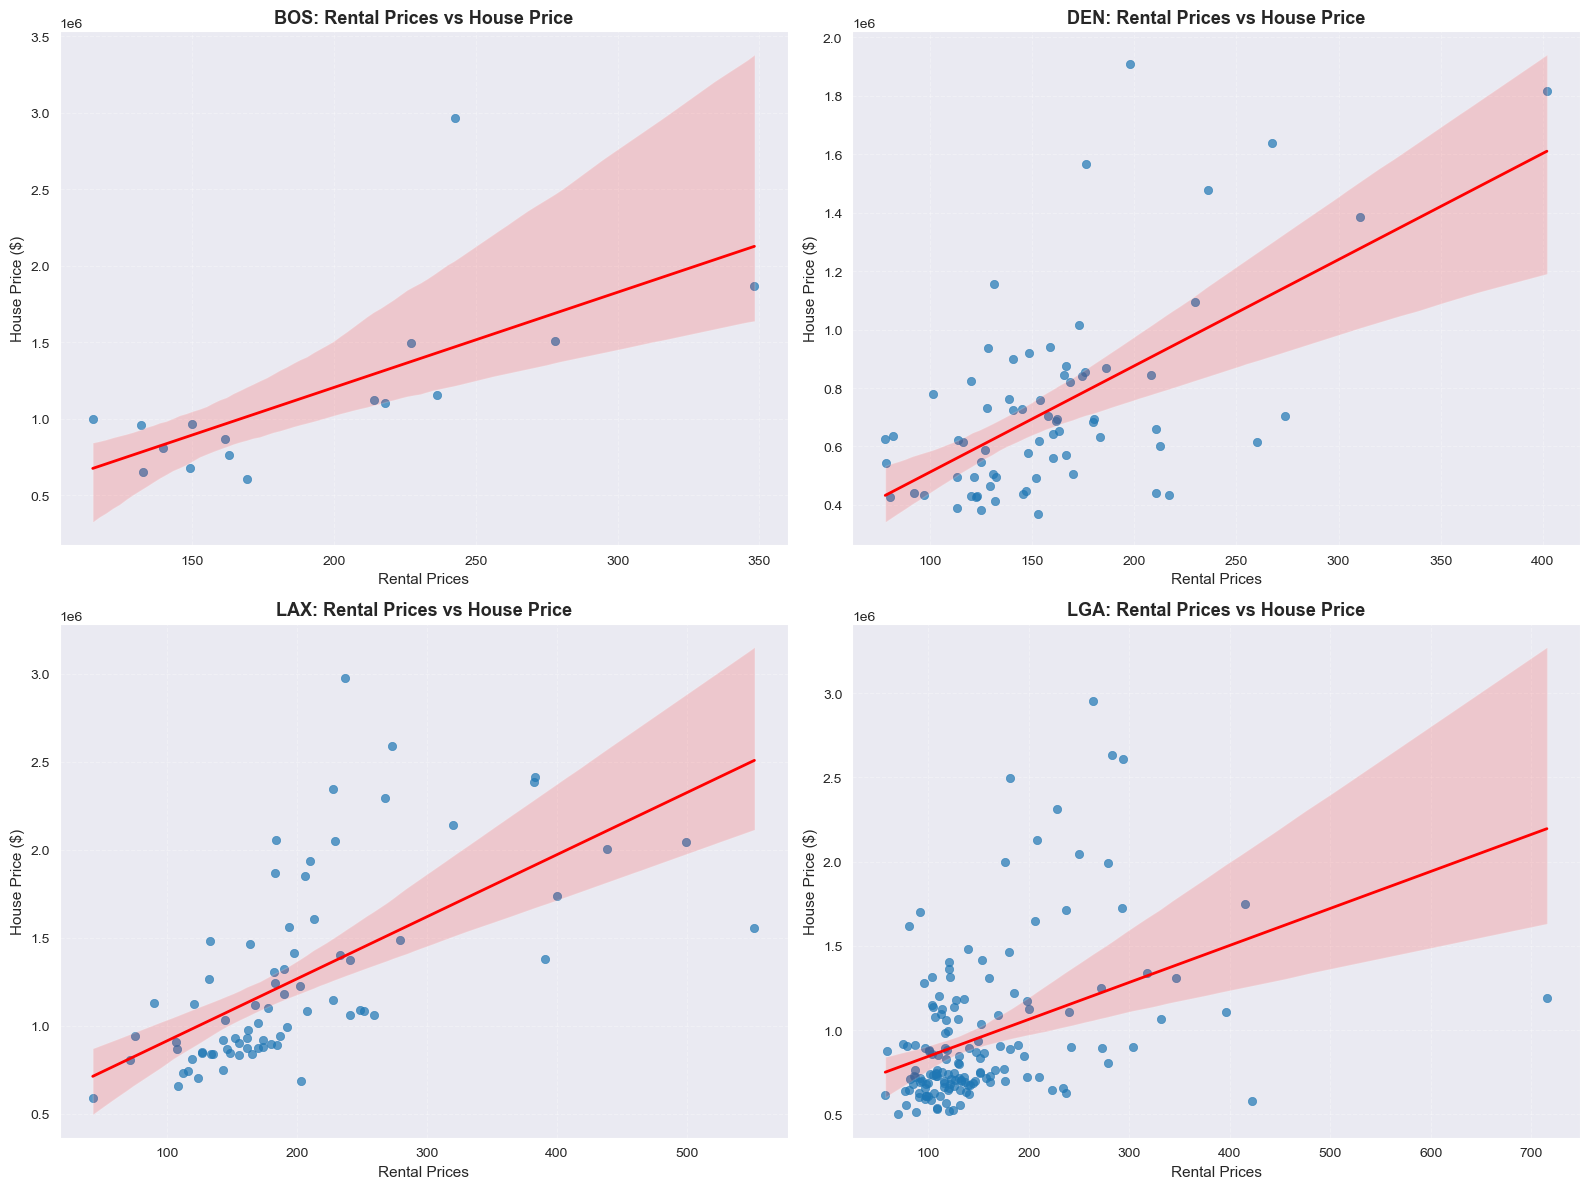

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for reasonable house prices
df_filtered = df[(df['house_value'] > 0) & (df['house_value'] < 3_000_000)]

cities = df_filtered['airport_code'].dropna().unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, city in enumerate(cities[:4]):  # Only plot up to 4 cities for 2x2 grid
    city_df = df_filtered[df_filtered['airport_code'] == city]
    sns.scatterplot(
        data=city_df,
        x='price',
        y='house_value',
        ax=axes[idx],
        alpha=0.7,
        edgecolor=None
    )
    # Add regression line
    sns.regplot(
        data=city_df,
        x='price',
        y='house_value',
        scatter=False,
        ax=axes[idx],
        color='red',
        line_kws={'linewidth': 2}
    )
    axes[idx].set_title(f'{city}: Rental Prices vs House Price', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Rental Prices', fontsize=11)
    axes[idx].set_ylabel('House Price ($)', fontsize=11)
    axes[idx].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Across all four cities, there is positive correlation between rental and housing prices. The strongest relationship are observed in Boston and Los Angeles, where it seems airbnb rates are closely tied to high property value indicating higher rental prices leads to higher house values. Hence, price can be key varialble for Multiple Regression Analysis.  

1. Distance from airport vs House Prices 

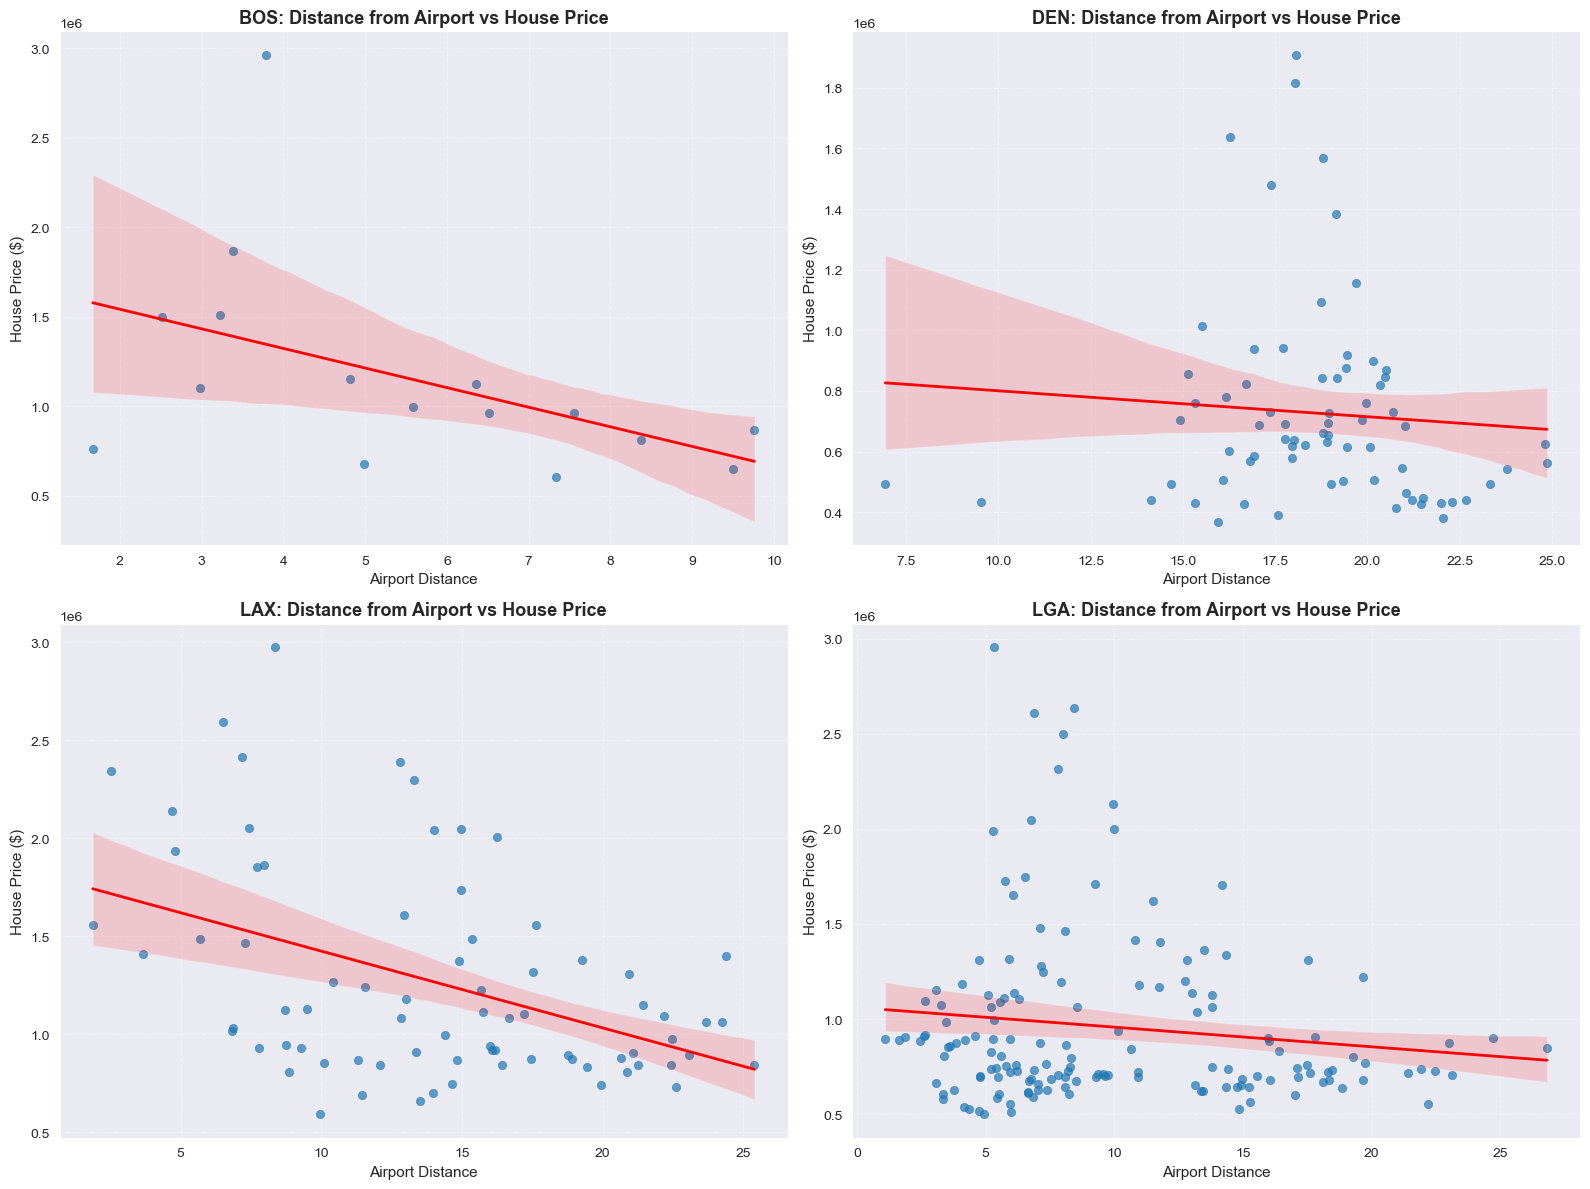

In [298]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for reasonable house prices
df_filtered = df[(df['house_value'] > 0) & (df['house_value'] < 3_000_000)]

cities = df_filtered['airport_code'].dropna().unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, city in enumerate(cities[:4]):  # Only plot up to 4 cities for 2x2 grid
    city_df = df_filtered[df_filtered['airport_code'] == city]
    sns.scatterplot(
        data=city_df,
        x='distance_from_airport',
        y='house_value',
        ax=axes[idx],
        alpha=0.7,
        edgecolor=None
    )
    # Add regression line
    sns.regplot(
        data=city_df,
        x='distance_from_airport',
        y='house_value',
        scatter=False,
        ax=axes[idx],
        color='red',
        line_kws={'linewidth': 2}
    )
    axes[idx].set_title(f'{city}: Distance from Airport vs House Price', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Airport Distance', fontsize=11)
    axes[idx].set_ylabel('House Price ($)', fontsize=11)
    axes[idx].grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

Boston : Positive correlation - house price decreases as distance from the airport increases indicating proximity to airport may enhance property value. 
Denver : Week correlation - Minimal change in house prices with varying distance from airport.
Los Angeles : Strong negative correlation - lower house prices with increase in distance from airport.
New York : Moderate negative correlation - House prices decreases with distance but trend is less steep and more spread out.
Week relationship between distance from airport and house prices are non linear and may not be a good candidate for Multiple Linear Regression but XGBoost can capture such non linearity and high dimensional data better.

print(df.head())

# Multiple Linear Regression  


Based on and linearity test,
Chosen Predictive Variables (X): {distance_from_airport, price (rental), long_term_stays, short_term_stay, population, passengers (volume), and visitors  }
Response Variable (Y): {house_value}

Check if model is useful for predicting house prices using Hypothesis test

In [299]:
# Reference HW2 - use train_house_data 
import statsmodels.api as sm
import patsy

#this seed has been set to 100 in all cells to ensure results are reproducible. DO NOT CHANGE THIS SEED
np.random.seed(100)
# Ref: HW4 
def forward_selection(X, y):
    initial_variables = X.columns.tolist()
    best_aic = float('inf')
    best_model = None
    selected_variables = ['const']

    while True:
        remaining_variables = [var for var in initial_variables if var not in selected_variables]
        new_aic = best_aic
        best_candidate = None

        for candidate in remaining_variables:
            temp_model = sm.Logit(y, X[selected_variables + [candidate]]).fit(disp=False)
            if temp_model.aic < new_aic:
                new_aic = temp_model.aic
                best_candidate = candidate

        if best_candidate:
            selected_variables.append(best_candidate)
            best_aic = new_aic
            best_model = sm.Logit(y, X[selected_variables]).fit(disp=False)
            print("Adding variable: ", best_candidate)
        else:
            break

    return best_model


# For Model based on the EDA - Manual variable selection
X_manual = df[['distance_from_airport', 'price', 'long_term_stays', 'short_term_stay', 'population','passengers','visitors']]  # 
y_manual = df['house_value']

# For Full Model
X_full = df[['price', 'availability_365', 'minimum_nights',  'long_term_stays', 
         'short_term_stay', 'reviews_per_month', 'number_of_reviews_ltm',
         'number_of_reviews_ltm.1', 'distance_from_airport',  'population',
         'neighbourhood_count',  'passengers',  'visitors' ]]  # 
y_full = df['house_value']

X = sm.add_constant(X_manual) # Add Intercept
df_model = pd.concat([X_manual, y_manual], axis=1)
df_model_clean = df_model.replace([np.inf, -np.inf], np.nan).dropna()
# Split back into X and y
X_clean = df_model_clean.drop(y_manual.name, axis=1)
y_clean = df_model_clean[y_manual.name]

# Fit the manual multiple linear regression model
mlr_manual = sm.OLS(y_clean, X_clean).fit()
print(mlr_manual.summary())

# Fit full model
mlr_full = sm.OLS(y_full, X_full).fit()

# Fit stepwise forward regression model
stepwise_forward = forward_selection(X_full, y_full)
#print(stepwise_forward.summary())




# Test of overall regression
alpha = 0.05
null_hypothesis = "H0: All regression coefficients are equal to zero (no relationship between predictors and response)"
alternative_hypothesis = "Ha: At least one regression coefficient is not equal to zero (there is a relationship between predictors and response)"
f_statistic = mlr_manual.fvalue
p_value = mlr_manual.f_pvalue

print("\nTest of Overall Regression:")
print(f"Null Hypothesis (H0): {null_hypothesis}")
print(f"Alternative Hypothesis (Ha): {alternative_hypothesis}")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.2e}")

if p_value < alpha:
    conclusion = "Reject the null hypothesis. The model is useful in predicting house prices."
else:
    conclusion = "Fail to reject the null hypothesis. The model is not useful in predicting house prices."

print(f"Conclusion: {conclusion}")

                            OLS Regression Results                            
Dep. Variable:            house_value   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     23.45
Date:                Wed, 23 Apr 2025   Prob (F-statistic):           7.25e-25
Time:                        00:25:46   Log-Likelihood:                -8806.4
No. Observations:                 588   AIC:                         1.763e+04
Df Residuals:                     581   BIC:                         1.766e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
distance_from_airport -4163.84

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

# Variable Selection - Forward Stepwise Regression

In [1]:
#this seed has been set to 100 in all cells to ensure results are reproducible. DO NOT CHANGE THIS SEED
np.random.seed(100)
X = df[['price', 'availability_365', 'minimum_nights',  'long_term_stays', 
        'short_term_stay', 'reviews_per_month', 'number_of_reviews_ltm',
        'number_of_reviews_ltm.1', 'distance_from_airport',  'population',
        'neighbourhood_count',  'passengers',  'visitors' ]]  # 
y = df['house_value']

X = sm.add_constant(X) # for better fit 
df_model = pd.concat([X, y], axis=1)
df_model_clean = df_model.replace([np.inf, -np.inf], np.nan).dropna()


# Split back into X and y
X_clean = df_model_clean.drop(y.name, axis=1)
y_clean = df_model_clean[y.name]

# Ensure all columns are numeric
X_clean = X_clean.apply(pd.to_numeric, errors='coerce')
y_clean = pd.to_numeric(y_clean, errors='coerce')

# Drop any remaining rows with missing values
mask = X_clean.notnull().all(axis=1) & y_clean.notnull()
X_clean = X_clean[mask]
y_clean = y_clean[mask]

# Check for duplicate columns
X_clean = X_clean.loc[:, ~X_clean.columns.duplicated()]

full_model = sm.OLS(y_clean,X_clean).fit()

def forward_selection(X_clean, y_clean):
    initial_variables = X_clean.columns.tolist()
    best_aic = float('inf')
    best_model = None
    selected_variables = ['const']

    while True:
        remaining_variables = [var for var in initial_variables if var not in selected_variables]
        new_aic = best_aic
        best_candidate = None

        for candidate in remaining_variables:
            temp_model = sm.OLS(y_clean, sm.add_constant(X_clean[selected_variables + [candidate]])).fit(disp=False)
            if temp_model.aic < new_aic:
                new_aic = temp_model.aic
                best_candidate = candidate

        if best_candidate:
            selected_variables.append(best_candidate)
            best_aic = new_aic
            best_model = sm.OLS(y_clean, sm.add_constant(X_clean[selected_variables])).fit(disp=False)
            print("Adding variable: ", best_candidate)
        else:
            break

    return best_model

stepwise_forward = forward_selection(X_clean, y_clean)

print(stepwise_forward.summary())

NameError: name 'np' is not defined